# Tiled clustering model
 
This example is similar as the example presented in Figure 1 in Covariate-moderated Empirical Bayes Matrix Factorization  Denault et al 2025  Matrix Factorization
 
**Model description:**


We simulate a matrix $Z=LF^t$  in which $  L $ (but not $  F $) depended on the
2-d locations of the data points. Specifically, we generated a
periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile
1, 2 or 3. For each data point $i$, we set
$\ell_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise
$\ell_{ik} = 0$. The $  F $ matrix, by contrast, was simulated from
a simple scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 +
\sum_{m=1}^M N(0, \sigma_m^2)$. We simulated homoskedastic noise with
$\tau_{ij} = 0.1$.
 

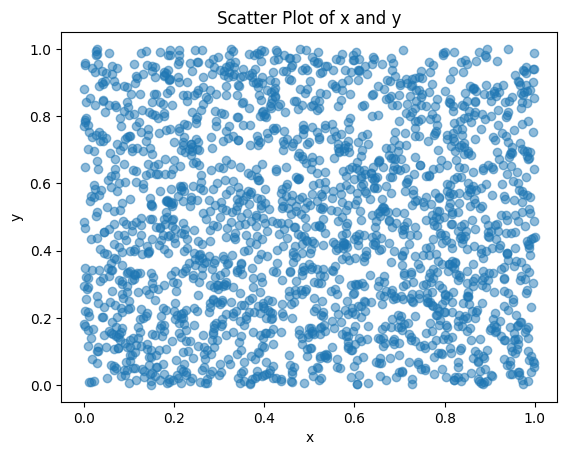

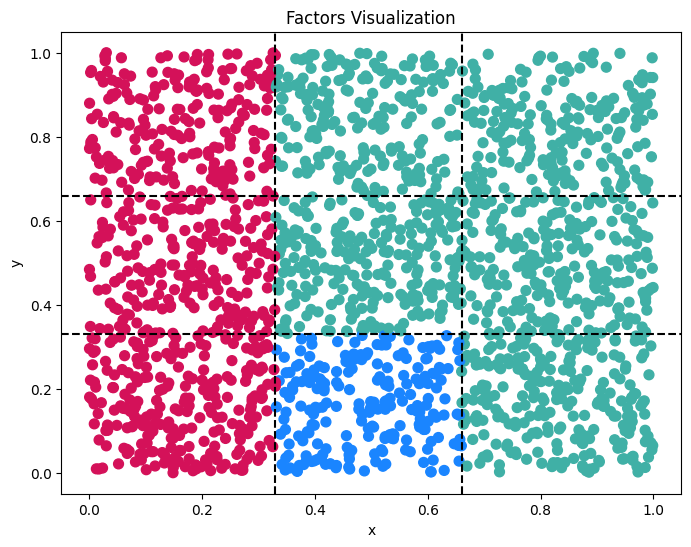

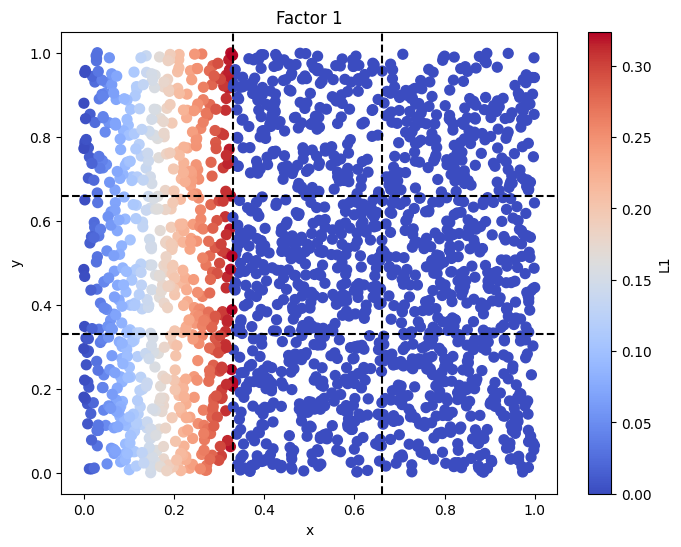

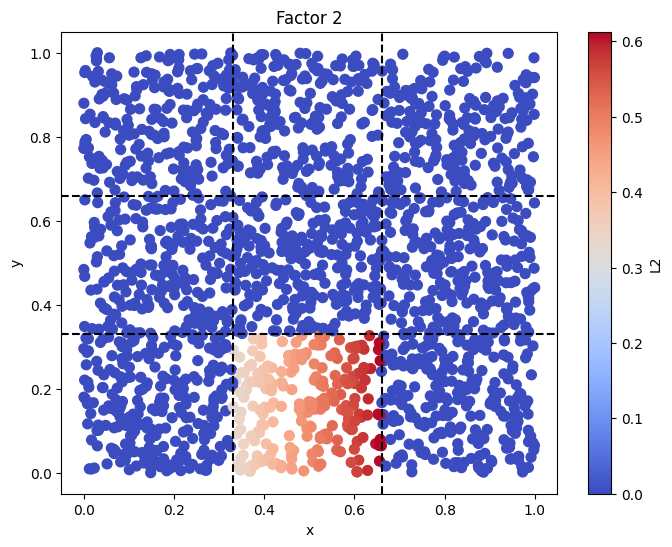

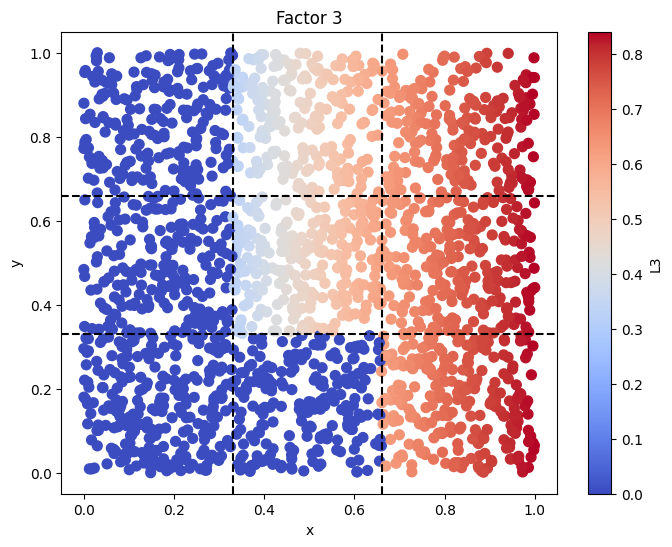

In [1]:
import torch
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(1)

# -------------------------
# 1) Random uniform data
# -------------------------
N = 2000
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N,2)

# Scatter of x vs y
plt.scatter(x.numpy(), y.numpy(), alpha=0.5)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Scatter Plot of x and y")
plt.show()

# -------------------------
# 2) Generate f (3 x 200)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# -------------------------
M = 200
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # 0/1
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # 0/1

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# -------------------------
# 3) Build L (N x 3) and factor labels
# -------------------------
L = torch.zeros(N, 3, dtype=torch.float32)

mask1 = x < 0.33
mask2 = (~mask1) & (x < 0.66) & (y < 0.33)
mask3 = ~(mask1 | mask2)

L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# -------------------------
# 4) Factor visualization
# -------------------------
colors = ["#D41159", "#1A85FF", "#40B0A6"]
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(8,6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=50)
for v in [0.33, 0.66]:
    plt.axhline(v, color="black", linestyle="--")
    plt.axvline(v, color="black", linestyle="--")
plt.title("Factors Visualization")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

# -------------------------
# 5) Individual factor plots (L1, L2, L3 as color)
# -------------------------
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()

# -------------------------
# 6) Generate Z = L @ f + noise
# -------------------------
Z = L @ f +  torch.randn(N, M) #* 2.5  # (N, M)


Fitting the model without account for the 2d side information

In [2]:
from cebmf_torch import cEBMF
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(10)

tensor(-2736.1907)
6004.62109375
tensor(-3268.4304)
tensor(-2748.5396)
3726.33740234375
tensor(-977.7979)
tensor(-2801.0483)
3777.234619140625
tensor(-976.1863)
tensor(-2842.8203)
3386.9482421875
tensor(-544.1279)
tensor(-2844.1504)
3381.3369140625
tensor(-537.1865)
tensor(-2759.9263)
5999.486328125
tensor(-3239.5601)
tensor(-2762.2852)
3691.16259765625
tensor(-928.8774)
tensor(-2901.8645)
3792.664306640625
tensor(-890.7998)
tensor(-3109.8567)
3454.2919921875
tensor(-344.4353)
tensor(-3104.7246)
3443.7939453125
tensor(-339.0693)
tensor(-2759.6592)
5995.11279296875
tensor(-3235.4536)
tensor(-2769.7317)
3693.907470703125
tensor(-924.1758)
tensor(-2931.5081)
3812.26123046875
tensor(-880.7532)
tensor(-3256.7021)
3521.49072265625
tensor(-264.7886)
tensor(-3254.4106)
3502.373046875
tensor(-247.9624)
tensor(-2758.0859)
5991.76513671875
tensor(-3233.6792)
tensor(-2778.1738)
3701.018798828125
tensor(-922.8450)
tensor(-2955.9443)
3833.0322265625
tensor(-877.0879)
tensor(-3374.0273)
3582.15234375

CEBMFResult(L=tensor([[-6.7598e+00, -1.4332e-02,  1.8322e+00,  7.3639e-09, -1.6797e-07],
        [-1.2728e-01, -8.6281e-02,  2.0286e+00,  6.0320e-08, -6.9689e-08],
        [-1.6566e+00, -1.5823e-02, -1.1584e-02, -3.5547e-08, -4.5247e-07],
        ...,
        [-6.3495e+00, -9.7502e-01,  1.8474e-02, -1.5775e-08,  5.1903e-07],
        [-1.1016e-01,  6.2751e-02,  2.8443e+00,  7.0512e-08, -1.3485e-08],
        [-9.9256e-02,  1.2566e-01,  1.3082e+00, -2.2849e-08,  6.4649e-08]]), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4925e-02,  1.7957e-20, -9.2337e-20],
        [ 1.6497e-01,  1.4324e-01,  3.9473e-04,  6.2231e-22, -4.8134e-20],
        [-5.1115e-04, -6.7892e-04,  5.7604e-02,  1.2628e-20, -2.6076e-19],
        [-5.5547e-02,  1.2525e-01,  6.6623e-02, -6.9376e-20,  2.1516e-20],
        [ 1.5923e-05, -2.8374e-02,  6.6553e-02, -1.1059e-19, -7.3182e-20],
        [ 1.1018e-03,  1.7563e-03, -4.5966e-04,  6.2999e-21,  1.4008e-20],
        [-1.2125e-05, -9.3930e-03, -5.1896e-04, -1.2304e-19, -1.7499e

Fitting the cEBMF model


Here we store the side information for the rows $L$ in the matrix $X$ that we pass in argument X_l (covariate for L)

[CASH] Epoch 10/20 | Loss: 318.4772
[CASH] Epoch 20/20 | Loss: 315.0236
tensor(-2837.6272)
5040.37744140625
tensor(-2202.7502)
[CASH] Epoch 10/20 | Loss: 205.6289
[CASH] Epoch 20/20 | Loss: 202.3860
tensor(-2892.6113)
3238.1757049560547
tensor(-345.5645)
[CASH] Epoch 10/20 | Loss: 219.3346
[CASH] Epoch 20/20 | Loss: 214.9968
tensor(-2901.5212)
3439.9495239257812
tensor(-538.4282)
[CASH] Epoch 10/20 | Loss: 209.1064
[CASH] Epoch 20/20 | Loss: 209.0528
tensor(-2826.2500)
3344.844207763672
tensor(-518.5942)
[CASH] Epoch 10/20 | Loss: 209.1634
[CASH] Epoch 20/20 | Loss: 208.8845
tensor(-2858.8066)
3342.152587890625
tensor(-483.3459)
[CASH] Epoch 10/20 | Loss: 315.7069
[CASH] Epoch 20/20 | Loss: 311.9263
tensor(-2831.6843)
4990.821304321289
tensor(-2159.1370)
[CASH] Epoch 10/20 | Loss: 203.9925
[CASH] Epoch 20/20 | Loss: 197.5661
tensor(-2839.4180)
3161.0570220947266
tensor(-321.6392)
[CASH] Epoch 10/20 | Loss: 214.2062
[CASH] Epoch 20/20 | Loss: 213.3369
tensor(-2880.7568)
3413.38970947265

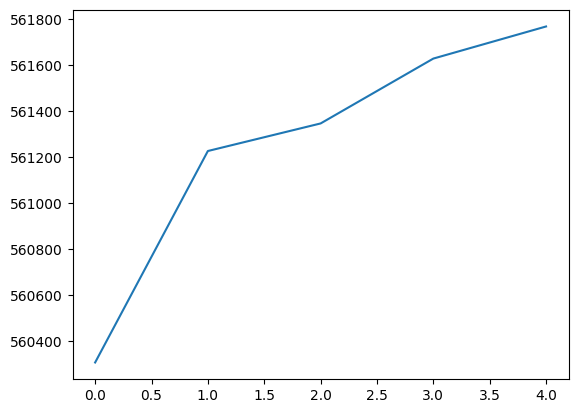

In [3]:
mycebmf11=  cEBMF(data=Z, X_l=X,
                 prior_L="cash" , allow_backfitting=False) 
mycebmf11.initialise_factors()
mycebmf11.fit(5)

plt.plot(mycebmf11.obj)

[CGB] Epoch 10/50, Loss=2.9931, mu2=-0.154, sigma2=6.657
[CGB] Epoch 20/50, Loss=2.9526, mu2=-0.310, sigma2=6.428
[CGB] Epoch 30/50, Loss=2.9279, mu2=-0.470, sigma2=6.525
[CGB] Epoch 40/50, Loss=2.9000, mu2=-0.632, sigma2=6.146
[CGB] Epoch 50/50, Loss=2.8860, mu2=-0.797, sigma2=6.152
tensor(-2863.8665)
5005.5712890625
tensor(-2141.7048)
[CGB] Epoch 10/50, Loss=1.7958, mu2=-0.112, sigma2=4.765
[CGB] Epoch 20/50, Loss=1.7158, mu2=-0.220, sigma2=4.101
[CGB] Epoch 30/50, Loss=1.6996, mu2=-0.344, sigma2=3.998
[CGB] Epoch 40/50, Loss=1.6940, mu2=-0.478, sigma2=3.687
[CGB] Epoch 50/50, Loss=1.6837, mu2=-0.619, sigma2=4.016
tensor(-2908.4604)
3256.214111328125
tensor(-347.7537)
[CGB] Epoch 10/50, Loss=1.9246, mu2=0.125, sigma2=2.397
[CGB] Epoch 20/50, Loss=1.8550, mu2=0.272, sigma2=2.534
[CGB] Epoch 30/50, Loss=1.8207, mu2=0.426, sigma2=2.511
[CGB] Epoch 40/50, Loss=1.7970, mu2=0.591, sigma2=1.476
[CGB] Epoch 50/50, Loss=1.7840, mu2=0.766, sigma2=1.578
tensor(-2985.2185)
3375.725830078125
tens

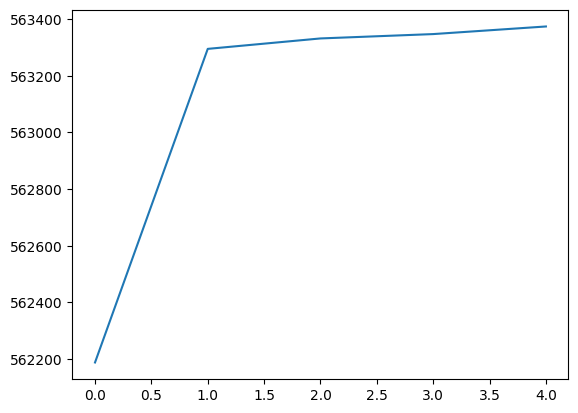

In [4]:
mycebmf12=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" , allow_backfitting=False) 
mycebmf12.initialise_factors()
mycebmf12.fit(5)

plt.plot(mycebmf12.obj)

[EMDN] Epoch 10/50, Loss: 2.6851
[EMDN] Epoch 20/50, Loss: 2.3012
[EMDN] Epoch 30/50, Loss: 1.5992
[EMDN] Epoch 40/50, Loss: 1.5648
[EMDN] Epoch 50/50, Loss: 1.5370
tensor(-2785.7542)
3054.98388671875
tensor(-269.2297)
[EMDN] Epoch 10/50, Loss: 1.7668
[EMDN] Epoch 20/50, Loss: 1.5332
[EMDN] Epoch 30/50, Loss: 1.5150
[EMDN] Epoch 40/50, Loss: 1.4955
[EMDN] Epoch 50/50, Loss: 1.4885
tensor(-2788.7756)
2976.97314453125
tensor(-188.1975)
[EMDN] Epoch 10/50, Loss: 1.6824
[EMDN] Epoch 20/50, Loss: 1.6179
[EMDN] Epoch 30/50, Loss: 1.5106
[EMDN] Epoch 40/50, Loss: 1.4951
[EMDN] Epoch 50/50, Loss: 1.4853
tensor(-2789.8867)
2967.62158203125
tensor(-177.7349)
[EMDN] Epoch 10/50, Loss: 1.6824
[EMDN] Epoch 20/50, Loss: 1.6812
[EMDN] Epoch 30/50, Loss: 1.6789
[EMDN] Epoch 40/50, Loss: 1.6761
[EMDN] Epoch 50/50, Loss: 1.6735
tensor(-2794.4812)
3349.45361328125
tensor(-554.9724)
[EMDN] Epoch 10/50, Loss: 1.6804
[EMDN] Epoch 20/50, Loss: 1.6749
[EMDN] Epoch 30/50, Loss: 1.6716
[EMDN] Epoch 40/50, Loss:

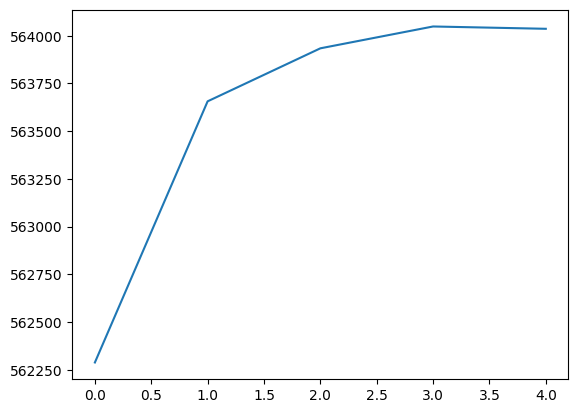

In [5]:
mycebmf13=  cEBMF(data=Z, X_l=X,
                 prior_L="emdn", allow_backfitting=False) 
mycebmf13.initialise_factors()
mycebmf13.fit(5)

plt.plot(mycebmf13.obj)

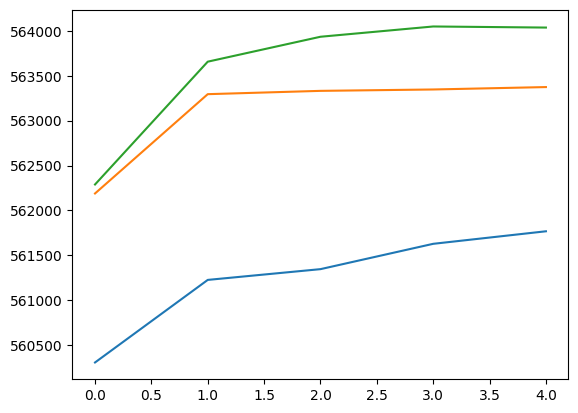

In [6]:
plt.plot(mycebmf11.obj)
plt.plot(mycebmf12.obj)
plt.plot(mycebmf13.obj)

tensor(0.0087)
tensor(0.0063)
tensor(0.0055)
tensor(0.0030)


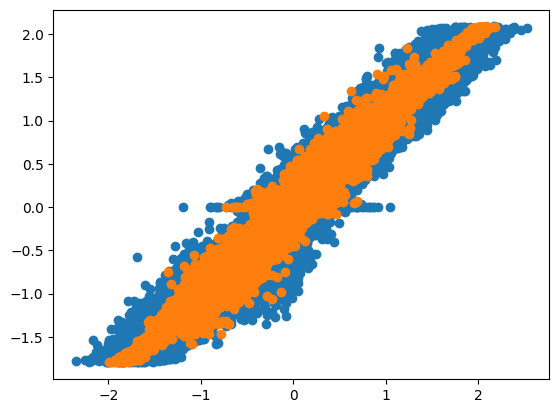

In [7]:
mycebmf._update_fitted_value()
mycebmf11._update_fitted_value()
mycebmf12._update_fitted_value()
mycebmf13._update_fitted_value()

plt.scatter(mycebmf.Y_fit,L@f)
plt.scatter(mycebmf13.Y_fit,L@f)
print(torch.mean((mycebmf.Y_fit-L@f).pow(2)))

print(torch.mean((mycebmf11.Y_fit-L@f).pow(2)))
print(torch.mean((mycebmf12.Y_fit-L@f).pow(2)))
print(torch.mean((mycebmf13.Y_fit-L@f).pow(2)))

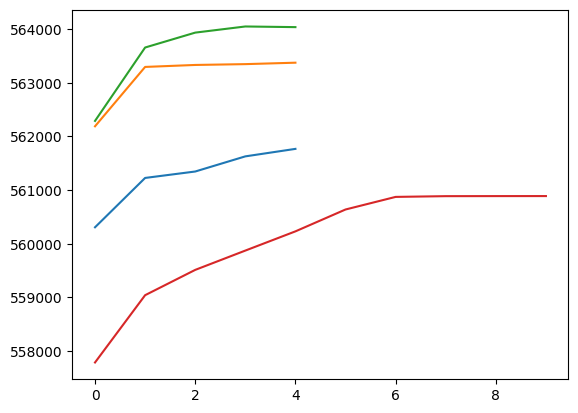

In [ ]:
 
plt.plot(mycebmf11.obj)

plt.plot(mycebmf12.obj)
plt.plot(mycebmf13.obj)
plt.plot(mycebmf .obj)

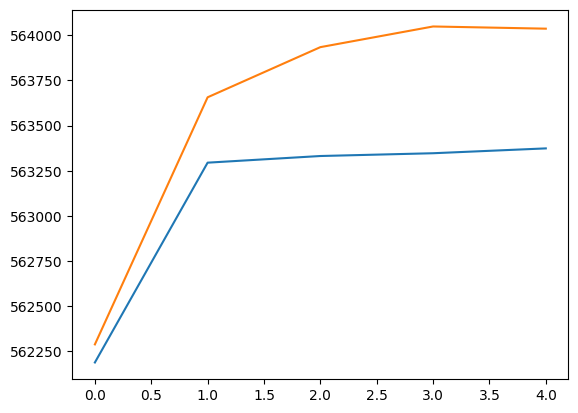

In [9]:
mycebmf11.kl_f

tensor([-431.4628, -272.4678, -232.0397, -139.6223, -111.5519])

In [10]:
mycebmf11.kl_l

tensor([-2150.5107,  -335.4070,  -509.3369,  -263.2034,  -185.7507])

In [11]:
mycebmf12.kl_l

tensor([-2.1021e+03, -3.2350e+02, -3.2966e+02, -1.9531e-03,  0.0000e+00])

In [12]:
mycebmf13.kl_l

tensor([-278.6123,  -71.8098,  -31.4568, -294.8467, -272.1543])

In [13]:
mycebmf.kl_l

tensor([-3.2302e+03, -9.2091e+02, -8.7076e+02, -2.7344e-02, -1.5625e-02])

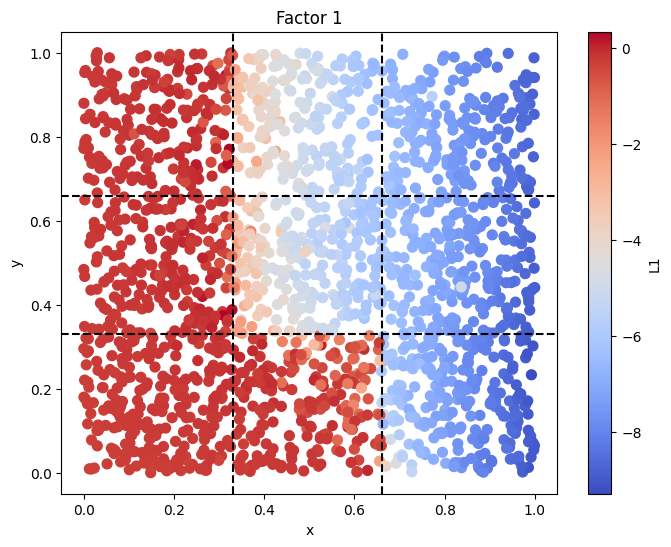

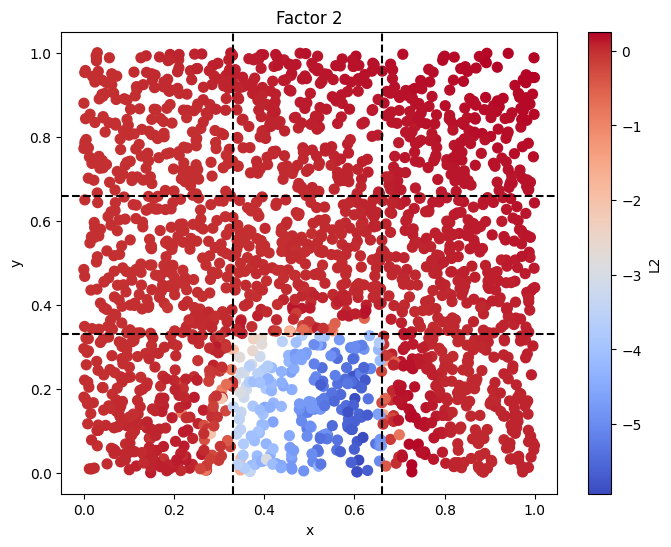

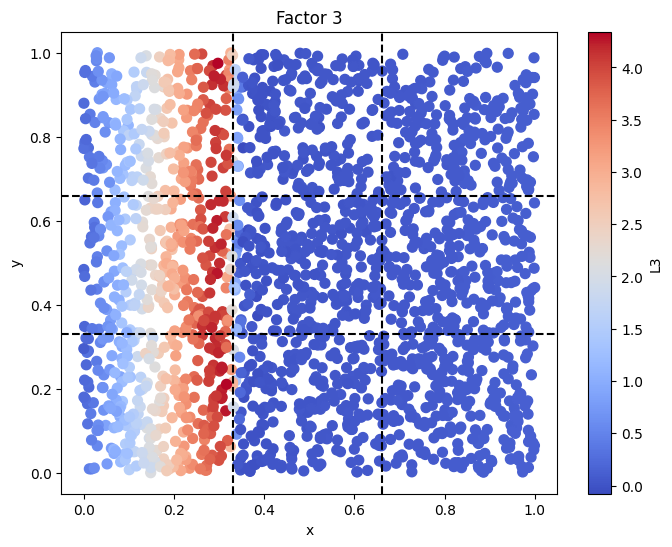

In [14]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf13.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


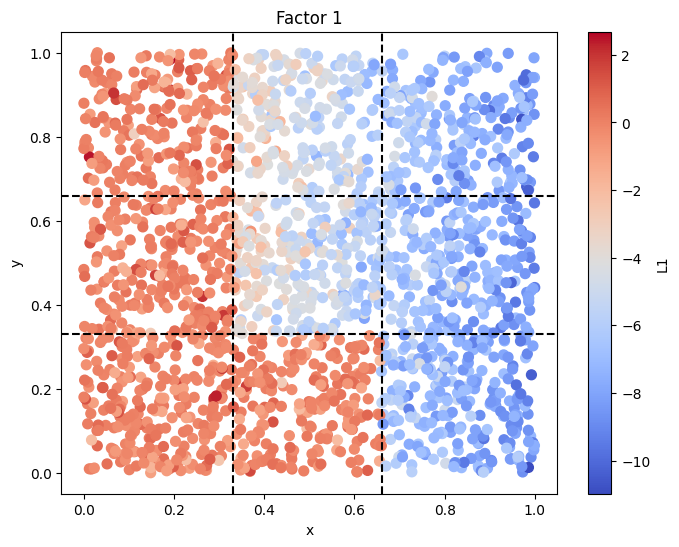

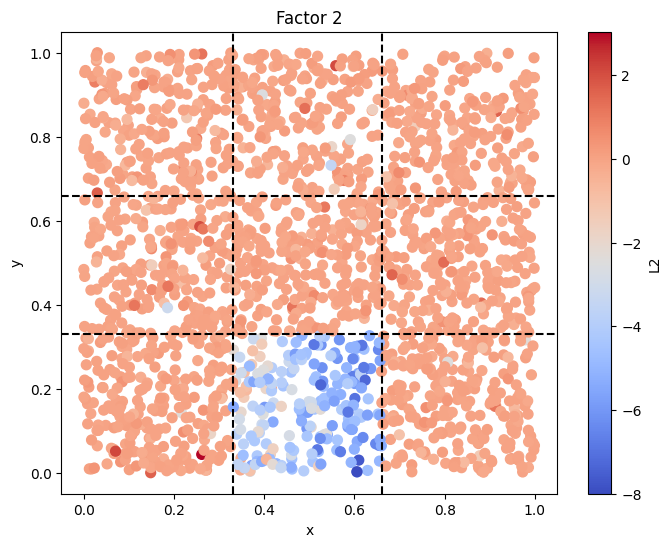

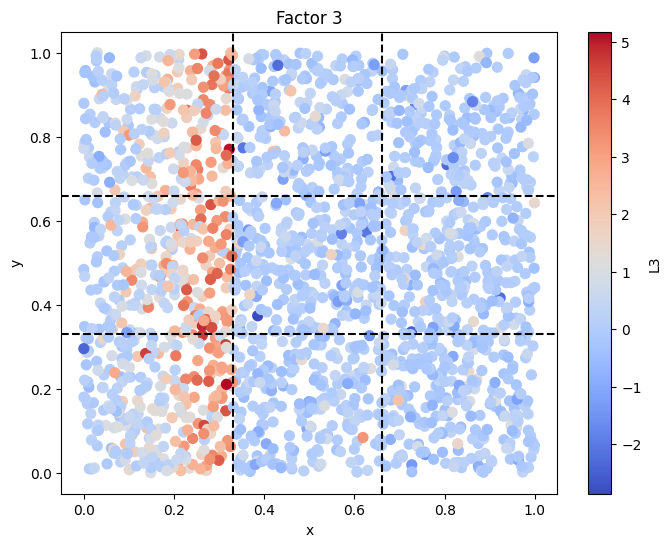

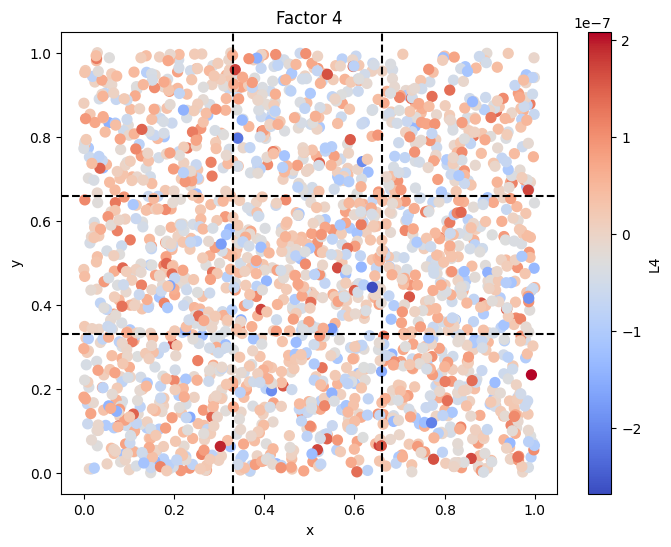

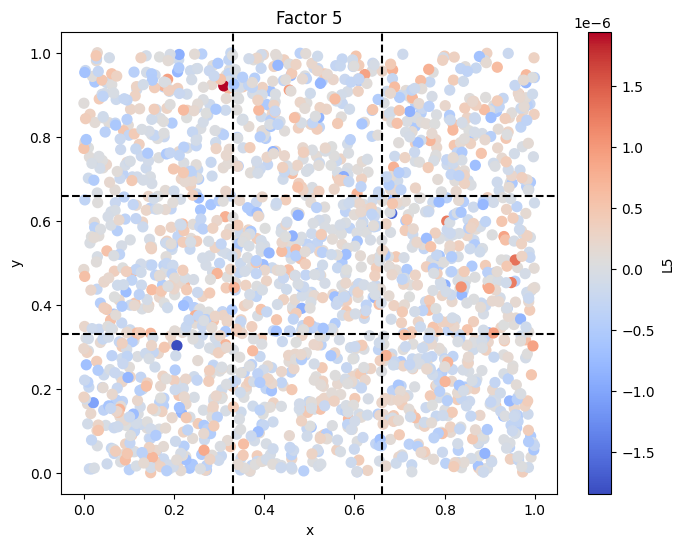

In [15]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


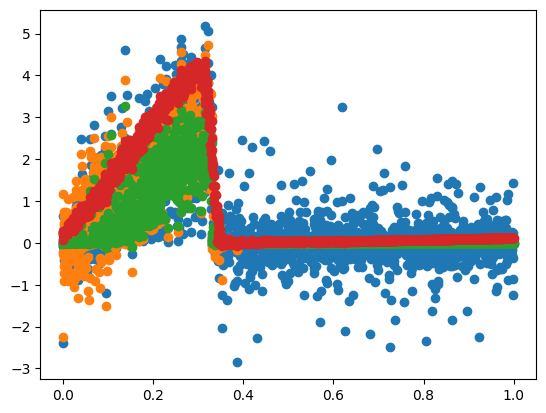

In [25]:
k=2

plt.scatter(x, mycebmf.L[:,k] )
plt.scatter( x,mycebmf11.L[:,k] )
plt.scatter( x,mycebmf12.L[:,k] )
plt.scatter( x,mycebmf13.L[:,k] )